### Required External Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import linregress ## Used for simplicity atm but could be done manually - likely with a small speed boost 

### Required Internal Libraries

In [14]:
import importlib 

import Functions.Universal 
importlib.reload(Functions.Universal)
from Functions.Universal import Build_mapping_dic, Chromosome_conversion


import Functions.Covariance 
importlib.reload(Functions.Covariance)
from Functions.Covariance import get_chunk_sizes, Calc_covariance

### Reading in the genome and converting it into a kmer array

In [131]:
Kmer_size = 4

Genome = "C:/users/henry chapman/Documents/Galaxy/Raw_data/E_coli/Escherichia_coli_ASM584v2.fna"

# Reading in the genome 
from Bio import SeqIO

for Chromosome in SeqIO.parse(Genome, "fasta"):
    print(Chromosome.id)
    Chromosome_seq = Chromosome.seq
    Chromosome_len = len(Chromosome_seq)


# building the mapping dictionary
Mapping_dic, Canonical_dic = Build_mapping_dic(Kmer_size = Kmer_size)

# Converting the chromosome into a numpy array of kmer indices 
Chr_kmer_arr = Chromosome_conversion(Kmer_size = Kmer_size, Chromosome_seq = Chromosome_seq, Chromosome_len = Chromosome_len, Mapping_dic = Mapping_dic)

U00096.3


### Calculating covariance across X number of randomly sampled chunks across the given chunk sizes

In [132]:
Chunk_sizes = [500, 1000, 2000, 5000, 10000, 15000, 20000, 25000, 30000, 35000, 40000, 45000]

# Calculate the covariances 
# Returns a thee dimensional array of covariances| Chunk_sizes | 136 | 136
# Type = "Proportion" or "Raw" - this likely need a "asset" check - but not critical atm. Just ensure that its spelt correctly
Chunks_kmer_cov = Calc_covariance(Chr_kmer_arr, Canonical_dic, Chunk_sizes, N_chunks = 10000, PseudoAddition = True, Type = "Proportion")

In [134]:
# Shape of : Chunk Sizes | Nummber of chunks | Kmer counts 
print(Chunks_kmer_cov.shape)

print(Chunks_kmer_cov[:,:,:].min())
print(Chunks_kmer_cov[:,:,:].max())

(12, 136, 136)
-1.7381346734016785e-05
5.9864520924621264e-05


### Fitting Linear and Quadratic functions for a single Kmer - Kmer pair

#### All Canonical Kmers - for typing in below

In [135]:
Canonical_dic

{'AAAA': 0,
 'AAAC': 1,
 'AAAG': 2,
 'AAAT': 3,
 'AACA': 4,
 'AACC': 5,
 'AACG': 6,
 'AACT': 7,
 'AAGA': 8,
 'AAGC': 9,
 'AAGG': 10,
 'AAGT': 11,
 'AATA': 12,
 'AATC': 13,
 'AATG': 14,
 'AATT': 15,
 'ACAA': 16,
 'ACAC': 17,
 'ACAG': 18,
 'ACAT': 19,
 'ACCA': 20,
 'ACCC': 21,
 'ACCG': 22,
 'ACCT': 23,
 'ACGA': 24,
 'ACGC': 25,
 'ACGG': 26,
 'ACGT': 27,
 'ACTA': 28,
 'ACTC': 29,
 'ACTG': 30,
 'AGAA': 31,
 'AGAC': 32,
 'AGAG': 33,
 'AGAT': 34,
 'AGCA': 35,
 'AGCC': 36,
 'AGCG': 37,
 'AGCT': 38,
 'AGGA': 39,
 'AGGC': 40,
 'AGGG': 41,
 'AGTA': 42,
 'AGTC': 43,
 'AGTG': 44,
 'ATAA': 45,
 'ATAC': 46,
 'ATAG': 47,
 'ATAT': 48,
 'ATCA': 49,
 'ATCC': 50,
 'ATCG': 51,
 'ATGA': 52,
 'ATGC': 53,
 'ATGG': 54,
 'ATTA': 55,
 'ATTC': 56,
 'ATTG': 57,
 'CAAA': 58,
 'CAAC': 59,
 'CAAG': 60,
 'CACA': 61,
 'CACC': 62,
 'CACG': 63,
 'CAGA': 64,
 'CAGC': 65,
 'CAGG': 66,
 'CATA': 67,
 'CATC': 68,
 'CATG': 69,
 'CCAA': 70,
 'CCAC': 71,
 'CCAG': 72,
 'CCCA': 73,
 'CCCC': 74,
 'CCCG': 75,
 'CCGA': 76,
 'CCGC': 

In [122]:
def KmerKmerInfo(Chunks_kmer_cov, Kmer1, Kmer2):
    
    # Retreive the kmer Indexes from the Mapping dictionary 
    Kmer1_ID = Mapping_dic[Kmer1]
    Kmer2_ID = Mapping_dic[Kmer2]

    # Retreiving the kmer Variances
    Kmer1_var = Chunks_kmer_cov[:,Kmer1_ID, Kmer1_ID]
    Kmer2_var = Chunks_kmer_cov[:,Kmer2_ID, Kmer2_ID]

    # Retreiving the kmer - kmer pair covariance
    KmerKmerCov = Chunks_kmer_cov[:, Kmer1_ID, Kmer2_ID]

    return Kmer1_var, Kmer2_var, KmerKmerCov


def LinearFitting(x, y):
    m, b = np.polyfit(x, y, 1)
    return m, b


def QuadraticFitting(x, y):
    a, b, c = np.polyfit(x, y, 2)
    return a, b, c



def ActualPlotting(x, y, color, subplot, title):

    # Get the linear fit 
    m, b = LinearFitting(x, y)
    FittedY = (m * x) + b

    # Plotting linear fit 
    plt.subplot(2,5,subplot)
    plt.title(f"{title}")
    plt.scatter(x, y, c = color)
    plt.plot(x, FittedY, c = "green")

    # Getting the quadratic fit 
    a, b, c = QuadraticFitting(x, y)
    FittedY = (a*x**2) + (b * x) + c

    # PLotting quadratic
    plt.subplot(2,5,(subplot+5))
    plt.title(f"{title}")
    plt.scatter(x, y, c = color)
    plt.plot(x, FittedY, c = "green")


def PlotKmerKmer(Chunks_kmer_cov, Kmer1, Kmer2, Chunk_sizes, LogX, LogY):
    
    if LogX:
        x = np.log10(np.array(Chunk_sizes, dtype = int))
    else:
        x = np.array(Chunk_sizes, dtype = int)
    
    # Reteeiving the kmers variances and covariances 
    Kmer1_var, Kmer2_var, KmerKmerCov = KmerKmerInfo(Chunks_kmer_cov, Kmer1, Kmer2)
    # calculating the Covariance decays 
    Kmer1_decay, Kmer2_decay = (KmerKmerCov / Kmer1_var), (KmerKmerCov / Kmer2_var)

    # Loopping through and plotting
    print("Positive values (Before doing abs) are shown in red, negative values in blue\nDecay refers to KmerKmerCovariance divide by KmerX variance")
    plt.figure(figsize = (22, 8))
    for subplot, (y, title) in enumerate([(Kmer1_var, Kmer1), (Kmer2_var, Kmer2), (KmerKmerCov, "KmerCov"), (Kmer1_decay, "Kmer1_decay"), (Kmer2_decay, "Kmer2_decay")]):
        c = ["red" if entry > 0 else "blue" for entry in y]
        if LogY:
            y = np.log10(np.abs(y))

        else : 
            y = np.abs(y)
            
        ActualPlotting(x, y, c, (subplot + 1), title)

    plt.show()

#### AAAC vs GCAT

Positive values (Before doing abs) are shown in red, negative values in blue
Decay refers to KmerKmerCovariance divide by KmerX variance


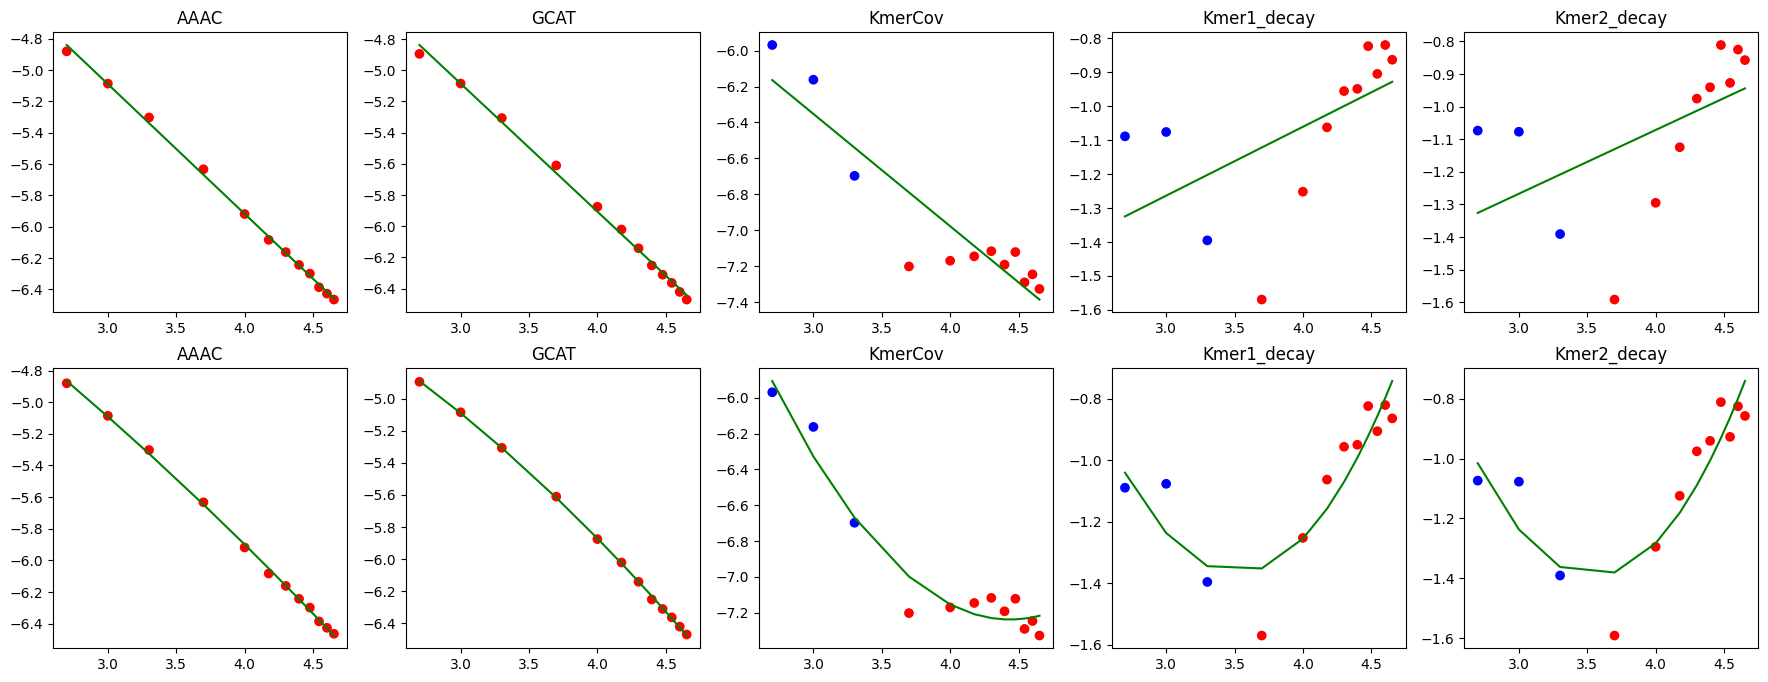

In [116]:
Kmer1 = "AAAC"
Kmer2 = "GCAT" 
LogX = True
LogY = True


PlotKmerKmer(Chunks_kmer_cov, Kmer1, Kmer2, Chunk_sizes, LogX, LogY)

#### GCGC vs GCAA

Positive values are shown in red, negative values in blue
Decay refers to KmerKmerCovariance divide by KmerX variance


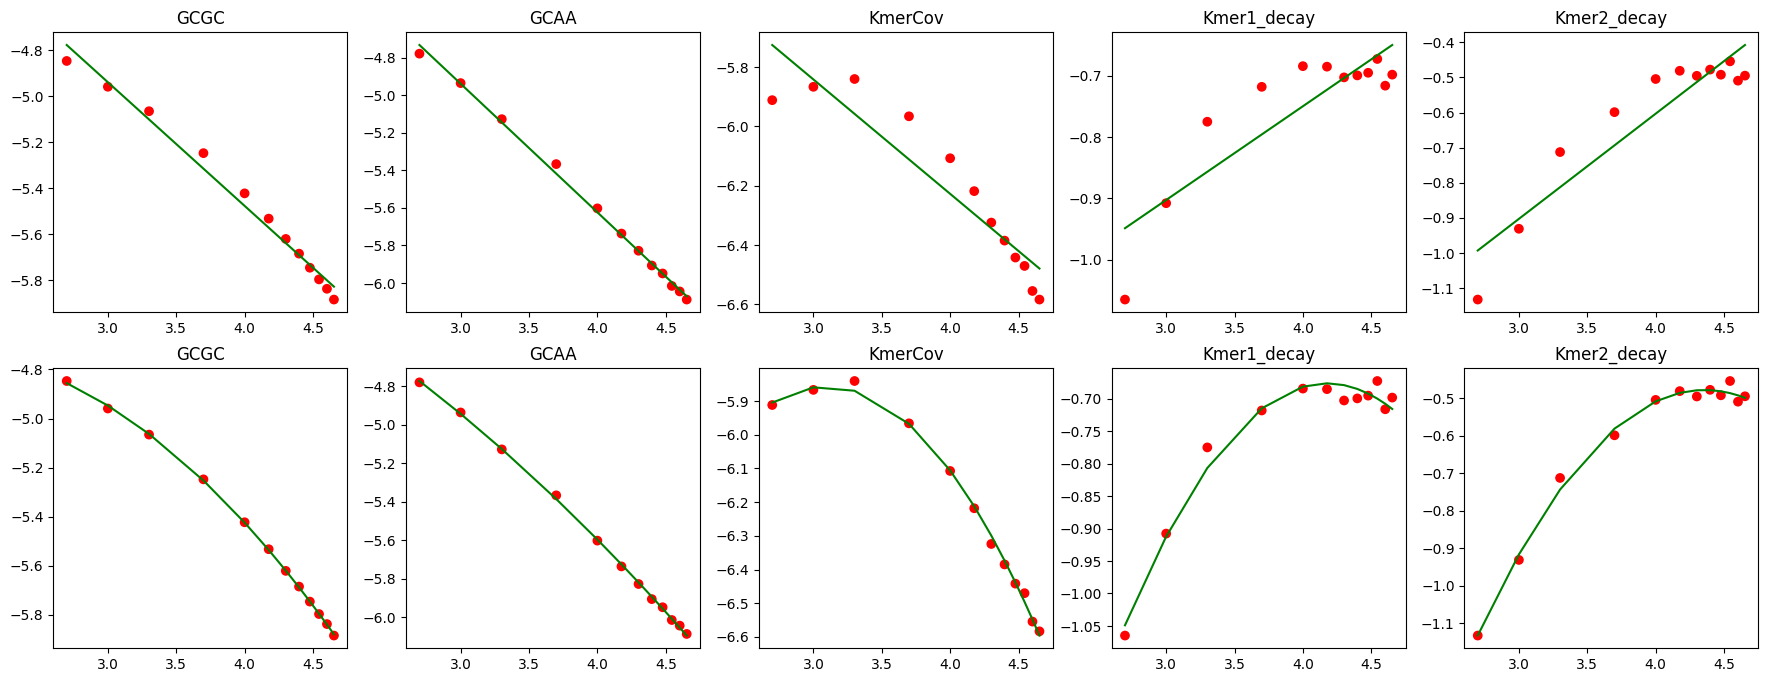

In [113]:
Kmer1 = "GCGC"
Kmer2 = "GCAA" 
LogX = True
LogY = True

PlotKmerKmer(Chunks_kmer_cov, Kmer1, Kmer2, Chunk_sizes, LogX, LogY)

#### ACTG vs GCAA

Positive values are shown in red, negative values in blue
Decay refers to KmerKmerCovariance divide by KmerX variance


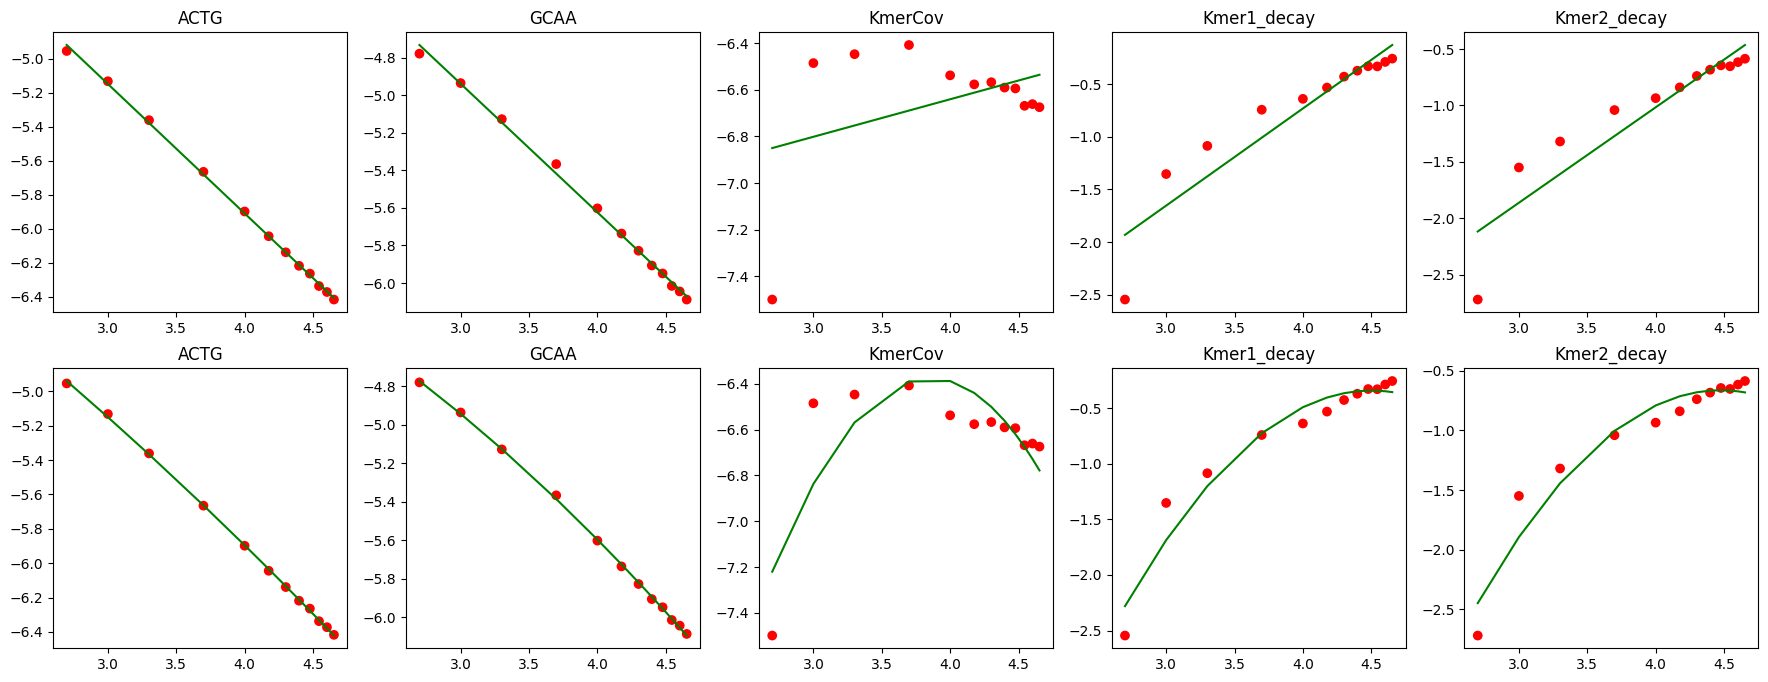

In [114]:
Kmer1 = "ACTG"
Kmer2 = "GCAA" 
LogX = True
LogY = True

PlotKmerKmer(Chunks_kmer_cov, Kmer1, Kmer2, Chunk_sizes, LogX, LogY)